In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
from sklearn import datasets
iris = datasets.load_iris()

In [21]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [22]:
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [23]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [24]:
iris['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [25]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [26]:
x=iris["data"][:,0].reshape(-1,1)
y=(iris["target"]==0).astype(int)

In [27]:
x[:3]

array([[5.1],
       [4.9],
       [4.7]])

In [28]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [29]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(solver="lbfgs",C=1,random_state=1)
log_reg.fit(x,y)
log_reg.intercept_,log_reg.coef_

(array([18.5496148]), array([[-3.45845643]]))

In [30]:
log_reg.score(x,y)

0.8933333333333333

In [31]:
x_new=[[5],[6.5]]
log_reg.predict(x_new)

array([1, 0])

In [32]:
log_reg.predict_proba(x_new)

array([[0.2214334 , 0.7785666 ],
       [0.98074142, 0.01925858]])

In [34]:
from sklearn.linear_model import SGDClassifier

sgd_clf=SGDClassifier(loss='log_loss',penalty='l2',alpha=0.0001,random_state=1)
sgd_clf.fit(x,y)
sgd_clf.intercept_,sgd_clf.coef_

(array([327.18126698]), array([[-60.97510431]]))

In [35]:
sgd_clf.score(x,y)

0.8933333333333333

In [36]:
x_new=[[5],[6.5]]
sgd_clf.predict(x_new)

array([1, 0])

In [37]:
sgd_clf.predict_proba(x_new)

array([[2.05464978e-10, 1.00000000e+00],
       [1.00000000e+00, 9.23708940e-31]])

In [38]:
decision_boundary=-log_reg.intercept_/log_reg.coef_
decision_boundary

array([[5.36355313]])

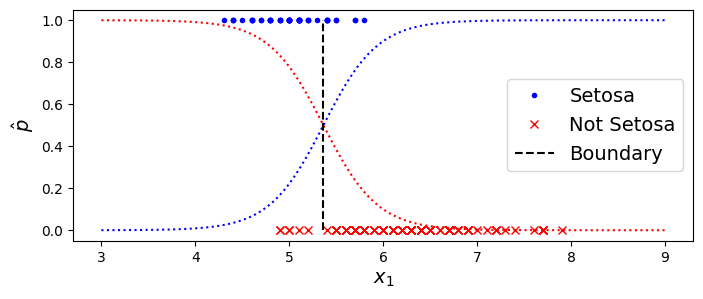

In [39]:
import matplotlib.pyplot as plt

xs=np.linspace(3,9,100).reshape(-1,1)
y_proba=log_reg.predict_proba(xs)

plt.figure(figsize=(8,3))
plt.plot(x[y==1],y[y==1],"b.",label="Setosa")
plt.plot(x[y==0],y[y==0],"rx",label="Not Setosa")

plt.plot(xs,y_proba[:,1],"r:")
plt.plot(xs,y_proba[:,0],"b:")

plt.plot([decision_boundary[0],decision_boundary[0]],[0,1],"k--",label='Boundary')

plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$\hat p$",fontsize=14)
plt.legend(loc="center right",fontsize=14)
plt.show()

In [40]:
x=iris["data"][:,:2]
y=(iris["target"]==2).astype(int)

In [41]:
x[:3]

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2]])

In [42]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [45]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression(solver="lbfgs",C=1,random_state=42)
log_reg.fit(x,y)
log_reg.intercept_,log_reg.coef_

(array([-12.52959903]), array([[ 2.22195969, -0.51274517]]))

In [46]:
log_reg.score(x,y)

0.8

In [47]:
x_new=[[5.5,2.8],[4.5,3.25]]
log_reg.predict(x_new)

array([0, 0])

In [48]:
log_reg.predict_proba(x_new)

array([[0.85125866, 0.14874134],
       [0.98518519, 0.01481481]])

In [50]:
x1_boundary=np.linspace(x.min(axis=0)[0]-0.05,x.max(axis=0)[0]+0.05,5)
x2_boundary=-(log_reg.intercept_+log_reg.coef_[0][0]*x1_boundary)/log_reg.coef_[0][1]
boundary=np.c_[x1_boundary,x2_boundary]
boundary

array([[ 4.25      , -6.01911147],
       [ 5.175     , -2.0106628 ],
       [ 6.1       ,  1.99778587],
       [ 7.025     ,  6.00623455],
       [ 7.95      , 10.01468322]])

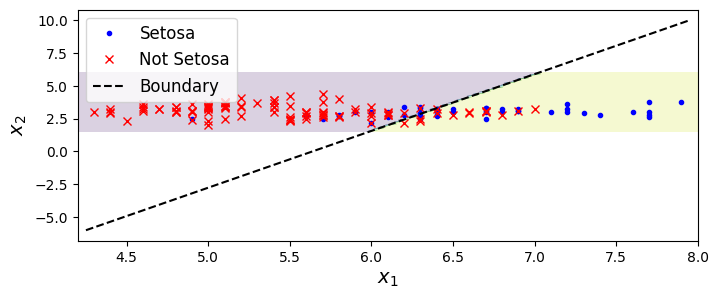

In [57]:
x1s=np.linspace(4.2,8,100).reshape(-1,1)
x2s=np.linspace(1.5,6,100).reshape(-1,1)

x1,x2=np.meshgrid(x1s,x2s)
x_new=np.c_[x1.ravel(),x2.ravel()]
y_pred=log_reg.predict(x_new)

plt.figure(figsize=(8,3))
plt.plot(x[y==1,0],x[y==1,1],"b.",label="Setosa")
plt.plot(x[y==0,0],x[y==0,1],"rx",label="Not Setosa")

zz=y_pred.reshape(x1.shape)
plt.contourf(x1,x2,zz,alpha=0.2)
plt.plot(boundary[:,0],boundary[:,1],"k--",label='Boundary')

plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$",fontsize=14)
plt.legend(loc="upper left",fontsize=12)
plt.show()